In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
true=pd.read_csv('true.csv')
fake=pd.read_csv('fake.csv')
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
fake['label']=0
true['label']=1

In [5]:
df=pd.concat([fake,true],axis=0)
df.sample(frac=1).reset_index(drop=True)

,title,text,subject,date,label
0,Prize-winning Cameroonian writer detained afte...,DOUALA (Reuters) - A celebrated Cameroonian wr...,worldnews,"December 8, 2017",1
1,South Korea says delay in military drills aime...,SEOUL (Reuters) - South Korean officials said ...,worldnews,"December 20, 2017",1
2,"In high-level talks, U.S. asks China to do mor...",WASHINGTON (Reuters) - The United States press...,politicsNews,"June 21, 2017",1
3,TRUMP HATER GEORGE RAMOS Promotes Movie Showin...,Mexico has been the beneficiary of our open bo...,politics,"Apr 20, 2016",0
4,ALERT: FLOOD OF CUBANS Breeze Across Texas Bor...,STOP the invasion of Cubans! The invasion of C...,Government News,"Feb 15, 2016",0
...,...,...,...,...,...
44893,Finger Wagging Maxine Waters on Illegal Aliens...,Maxine Waters is one angry woman. She has gone...,left-news,"Sep 18, 2017",0
44894,Iraq opposed to U.S. recognition of Jerusalem ...,BAGHDAD (Reuters) - Iraq is opposed to the Uni...,worldnews,"December 5, 2017",1
44895,(VIDEO) JUDGE JEANINE: FREE SPEECH IS NON-NEGO...,,Government News,"May 10, 2015",0
44896,WATCH: ARROGANT Sexual Predator and Sometimes ...,The not so funny comedian Louis C.K. appeared ...,left-news,"Nov 9, 2017",0


In [6]:
df.drop(columns=['subject','date'],inplace=True)

In [7]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   44898 non-null  object
 1   text    44898 non-null  object
 2   label   44898 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [9]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
df.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [11]:
df['content']=df['title']+" "+df['text']

In [12]:
df.head()

,title,text,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0,Pope Francis Just Called Out Donald Trump Dur...


In [13]:
df.drop(columns=['title','text'],inplace=True)

In [14]:
df.head()

,label,content
0,0,Donald Trump Sends Out Embarrassing New Year’...
1,0,Drunk Bragging Trump Staffer Started Russian ...
2,0,Sheriff David Clarke Becomes An Internet Joke...
3,0,Trump Is So Obsessed He Even Has Obama’s Name...
4,0,Pope Francis Just Called Out Donald Trump Dur...


In [15]:
import nltk

In [16]:
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [17]:
df['num_char']=df['content'].apply(len)

In [18]:
df['num_words']=df['content'].apply(lambda x:len(nltk.word_tokenize(x)))

In [19]:
df['num_sent']=df['content'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [20]:
df.head()

,label,content,num_char,num_words,num_sent
0,0,Donald Trump Sends Out Embarrassing New Year’...,2973,614,28
1,0,Drunk Bragging Trump Staffer Started Russian ...,1968,339,11
2,0,Sheriff David Clarke Becomes An Internet Joke...,3688,706,25
3,0,Trump Is So Obsessed He Even Has Obama’s Name...,2853,537,15
4,0,Pope Francis Just Called Out Donald Trump Dur...,2417,469,19


In [21]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [22]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

ps = PorterStemmer()

def transform(content):
    content = content.lower()
    content = nltk.word_tokenize(content)

    y = []
    
    # Remove special characters
    for i in content:
        if i.isalnum():
            y.append(i)

    content = y[:]
    y.clear()

    # Remove stopwords & punctuation
    for i in content:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    content = y[:]
    y.clear()

    # Stemming
    for i in content:
        y.append(ps.stem(i))

    return " ".join(y)

In [23]:
df['transform_content']=df['content'].apply(transform)

In [24]:
df.head()

,label,content,num_char,num_words,num_sent,transform_content
0,0,Donald Trump Sends Out Embarrassing New Year’...,2973,614,28,donald trump send embarrass new year eve messa...
1,0,Drunk Bragging Trump Staffer Started Russian ...,1968,339,11,drunk brag trump staffer start russian collus ...
2,0,Sheriff David Clarke Becomes An Internet Joke...,3688,706,25,sheriff david clark becom internet joke threat...
3,0,Trump Is So Obsessed He Even Has Obama’s Name...,2853,537,15,trump obsess even obama name code websit imag ...
4,0,Pope Francis Just Called Out Donald Trump Dur...,2417,469,19,pope franci call donald trump christma speech ...


In [47]:
df['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [30]:
X=df['transform_content']
y=df['label']

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
tfidf=TfidfVectorizer(max_features=5000,stop_words='english')
X_train=tfidf.fit_transform(X_train)
X_test=tfidf.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5).astype(int)

In [48]:
print(np.unique(y_pred,return_counts=True))

(array([0, 1]), array([4714, 4266]))


In [38]:
from sklearn.metrics import  accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4733
           1       0.98      0.99      0.99      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [39]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[4661   72]
 [  53 4194]]


In [40]:
print(accuracy_score(y_test,y_pred))

0.9860801781737194


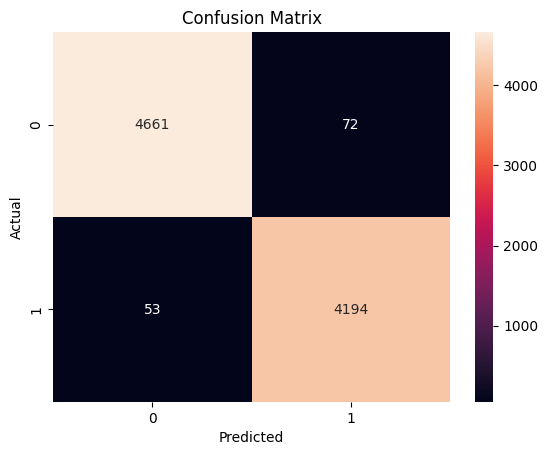

In [41]:
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [50]:
news=['you have a joining letter']
new_trans=tfidf.transform(news)
prediction=model.predict(new_trans)
print('Prediction :',prediction)

Prediction : [0]


In [43]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(X_train,y_train)
y_pred_nb=nb.predict(X_test)
print('Naive Bayes Accuarcy :',accuracy_score(y_test,y_pred_nb))

Naive Bayes Accuarcy : 0.9210467706013363


In [53]:
news=['you won lottery']
new_trans=tfidf.transform(news)
prediction=nb.predict(new_trans)
print('Prediction :',prediction)

Prediction : [0]


In [54]:
import pickle
pickle.dump(nb,open('nb_model.pkl','wb'))
pickle.dump(tfidf,open('tfidf.pkl','wb'))
